----- Clustering Evaluation -----
K-Means Silhouette Score: 0.4529
EM (GMM) Silhouette Score: 0.4425


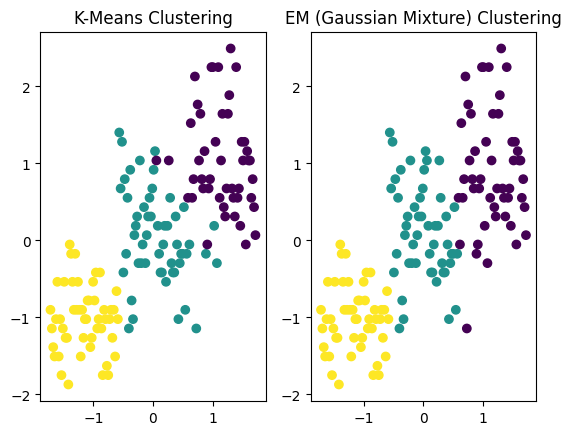


----- Conclusion -----
K-Means performed as well as or better than EM.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

df = pd.read_csv("iris.csv")

X = df.select_dtypes(include=[np.number])

true_labels = None
if 'species' in df.columns:
    true_labels = df['species'].astype('category').cat.codes

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)

print("----- Clustering Evaluation -----")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"EM (GMM) Silhouette Score: {gmm_silhouette:.4f}")

if true_labels is not None:
    kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
    gmm_ari = adjusted_rand_score(true_labels, gmm_labels)

    print(f"K-Means ARI: {kmeans_ari:.4f}")
    print(f"EM (GMM) ARI: {gmm_ari:.4f}")

plt.figure()

# Plot K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")

# Plot EM (GMM)
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.title("EM (Gaussian Mixture) Clustering")

plt.show()

print("\n----- Conclusion -----")

if gmm_silhouette > kmeans_silhouette:
    print("EM (GMM) produced better-defined clusters than K-Means.")
else:
    print("K-Means performed as well as or better than EM.")